In [1]:
from copy import deepcopy
from dataclasses import asdict, dataclass
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


TASKS = ["Baseline", "Logic", "Nback", "Stroop", "Sudoku"]
STRESS_TASKS = {"Logic", "Nback", "Stroop", "Sudoku"}


@dataclass
class HyperParameters:
    split_train_subjects: int = 35
    split_val_subjects: int = 5
    split_test_subjects: int = 10
    random_seed: int = 42

    window_size: int = 60
    stride: int = 10
    batch_size: int = 64
    epochs: int = 50
    learning_rate: float = 1e-3
    dropout_rate: float = 0.3
    weight_decay: float = 1e-4
    patience: int = 8

    transformer_heads: int = 8
    transformer_layers: int = 2
    transformer_ff_dim: int = 256
    transformer_dropout: float = 0.1

    use_cuda: bool = True
    save_model: bool = True

    # subject_zscore | baseline_zscore | none
    normalization_mode: str = "subject_zscore"

    # focal | weighted_bce
    loss_name: str = "focal"
    focal_gamma: float = 2.0
    focal_alpha: Optional[float] = None


def find_dataset_root() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / "Dataset" / "CATSA"
        if candidate.exists():
            return candidate

    fallback = Path("/home/binghin2/Myproject/Dataset/CATSA")
    if fallback.exists():
        return fallback

    raise FileNotFoundError("Could not find Dataset/CATSA. Please set dataset_root manually.")


def discover_complete_subjects(dataset_root: Path) -> List[str]:
    subjects: List[str] = []
    for subject_dir in sorted(dataset_root.glob("Sub*"), key=lambda p: int(p.name[3:])):
        if not subject_dir.is_dir():
            continue
        has_all = all((subject_dir / task / "HR.csv").exists() for task in TASKS)
        if has_all:
            subjects.append(subject_dir.name)
    return subjects


def split_subjects(subjects: List[str], hp: HyperParameters) -> Dict[str, List[str]]:
    expected = hp.split_train_subjects + hp.split_val_subjects + hp.split_test_subjects
    if len(subjects) < expected:
        raise ValueError(f"Need at least {expected} complete subjects, but found {len(subjects)}")

    rng = np.random.default_rng(hp.random_seed)
    shuffled = subjects.copy()
    rng.shuffle(shuffled)

    selected = shuffled[:expected]
    train_end = hp.split_train_subjects
    val_end = train_end + hp.split_val_subjects

    return {
        "train": sorted(selected[:train_end], key=lambda x: int(x[3:])),
        "val": sorted(selected[train_end:val_end], key=lambda x: int(x[3:])),
        "test": sorted(selected[val_end:], key=lambda x: int(x[3:])),
    }


def read_hr_csv(file_path: Path) -> np.ndarray:
    df = pd.read_csv(file_path)
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if numeric_cols:
        values = df[numeric_cols[0]].to_numpy(dtype=np.float32)
    else:
        values = pd.to_numeric(df.iloc[:, 0], errors="coerce").to_numpy(dtype=np.float32)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        raise ValueError(f"No valid HR values in {file_path}")
    return values


def sliding_windows(signal: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    if len(signal) < window_size:
        return np.empty((0, window_size), dtype=np.float32)
    windows = [signal[i:i + window_size] for i in range(0, len(signal) - window_size + 1, stride)]
    return np.asarray(windows, dtype=np.float32)


def compute_subject_stats(sub_path: Path, use_baseline_as_non_stress: bool, use_stress_tasks_only: bool) -> Tuple[float, float]:
    if use_stress_tasks_only:
        candidate_tasks = [t for t in TASKS if t in STRESS_TASKS]
    else:
        candidate_tasks = TASKS.copy()

    values_list: List[np.ndarray] = []
    for task in candidate_tasks:
        if task == "Baseline" and not use_baseline_as_non_stress:
            continue
        values_list.append(read_hr_csv(sub_path / task / "HR.csv"))

    all_values = np.concatenate(values_list, axis=0)
    sub_mean = float(np.mean(all_values))
    sub_std = float(np.std(all_values)) + 1e-8
    return sub_mean, sub_std


def build_split_arrays(
    dataset_root: Path,
    subject_list: List[str],
    window_size: int,
    stride: int,
    normalization_mode: str = "subject_zscore",
    use_baseline_as_non_stress: bool = True,
    use_stress_tasks_only: bool = False,
) -> Tuple[np.ndarray, np.ndarray]:
    x_chunks: List[np.ndarray] = []
    y_chunks: List[np.ndarray] = []

    for sub in subject_list:
        sub_path = dataset_root / sub
        baseline = read_hr_csv(sub_path / "Baseline" / "HR.csv")
        baseline_mean = float(np.mean(baseline))
        baseline_std = float(np.std(baseline)) + 1e-8

        sub_mean, sub_std = compute_subject_stats(
            sub_path,
            use_baseline_as_non_stress=use_baseline_as_non_stress,
            use_stress_tasks_only=use_stress_tasks_only,
        )

        if use_stress_tasks_only:
            candidate_tasks = [t for t in TASKS if t in STRESS_TASKS]
        else:
            candidate_tasks = TASKS.copy()

        for task in candidate_tasks:
            if task == "Baseline" and not use_baseline_as_non_stress:
                continue

            raw = read_hr_csv(sub_path / task / "HR.csv")
            if normalization_mode == "subject_zscore":
                norm = (raw - sub_mean) / sub_std
            elif normalization_mode == "baseline_zscore":
                norm = (raw - baseline_mean) / baseline_std
            elif normalization_mode == "none":
                norm = raw
            else:
                raise ValueError(f"Unknown normalization_mode: {normalization_mode}")

            windows = sliding_windows(norm, window_size=window_size, stride=stride)
            if len(windows) == 0:
                continue

            label = 1 if task in STRESS_TASKS else 0
            labels = np.full((len(windows),), label, dtype=np.int64)
            x_chunks.append(windows)
            y_chunks.append(labels)

    if not x_chunks:
        raise ValueError("No samples generated. Check data files or window settings.")

    x = np.concatenate(x_chunks, axis=0)[:, np.newaxis, :]
    y = np.concatenate(y_chunks, axis=0)
    return x.astype(np.float32), y.astype(np.int64)


class HR1DCNNTransformer(nn.Module):
    def __init__(self, hp: HyperParameters):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=hp.transformer_heads,
            dim_feedforward=hp.transformer_ff_dim,
            dropout=hp.transformer_dropout,
            batch_first=True,
            activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=hp.transformer_layers,
        )

        self.max_len = max(16, hp.window_size)
        self.pos_embedding = nn.Parameter(torch.zeros(1, self.max_len, 128))

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(hp.dropout_rate),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cnn(x)
        x = x.transpose(1, 2)  # [B, L, C]

        seq_len = x.size(1)
        if seq_len > self.pos_embedding.size(1):
            pos = nn.functional.interpolate(
                self.pos_embedding.transpose(1, 2),
                size=seq_len,
                mode="linear",
                align_corners=False,
            ).transpose(1, 2)
        else:
            pos = self.pos_embedding[:, :seq_len, :]

        x = x + pos
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x).squeeze(1)


class BinaryFocalLossWithLogits(nn.Module):
    def __init__(self, gamma: float = 2.0, alpha: Optional[float] = None, pos_weight: Optional[torch.Tensor] = None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        if pos_weight is not None:
            self.register_buffer("pos_weight", pos_weight)
        else:
            self.pos_weight = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
            pos_weight=self.pos_weight,
        )
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1.0 - probs) * (1.0 - targets)
        focal_factor = (1.0 - pt).pow(self.gamma)

        if self.alpha is not None:
            alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
            loss = alpha_t * focal_factor * bce
        else:
            loss = focal_factor * bce

        return loss.mean()


def compute_pos_weight(y: np.ndarray) -> torch.Tensor:
    pos = float(np.sum(y == 1))
    neg = float(np.sum(y == 0))
    if pos == 0:
        return torch.tensor([1.0], dtype=torch.float32)
    return torch.tensor([neg / pos], dtype=torch.float32)


def make_criterion(y_train: np.ndarray, hp: HyperParameters, device: torch.device) -> Tuple[nn.Module, Dict[str, object]]:
    pos_weight = compute_pos_weight(y_train).to(device)

    if hp.loss_name == "weighted_bce":
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight), {
            "loss_name": "weighted_bce",
            "pos_weight": float(pos_weight.item()),
            "focal_gamma": 0.0,
            "focal_alpha": 0.0,
        }

    if hp.loss_name == "focal":
        pos = float(np.sum(y_train == 1))
        neg = float(np.sum(y_train == 0))
        alpha = hp.focal_alpha
        if alpha is None:
            alpha = neg / max(pos + neg, 1.0)

        criterion = BinaryFocalLossWithLogits(
            gamma=hp.focal_gamma,
            alpha=float(alpha),
            pos_weight=None,
        )
        return criterion, {
            "loss_name": "focal",
            "pos_weight": 1.0,
            "focal_gamma": float(hp.focal_gamma),
            "focal_alpha": float(alpha),
            "weighting_note": "Focal uses alpha only to avoid duplicate class weighting",
        }

    raise ValueError(f"Unknown loss_name: {hp.loss_name}")


def make_loader(x: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool, pin_memory: bool = False) -> DataLoader:
    ds = TensorDataset(torch.from_numpy(x), torch.from_numpy(y).float())
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=pin_memory)


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device) -> Dict[str, float]:
    model.eval()
    total_loss = 0.0
    total = 0
    tp = tn = fp = fn = 0

    non_blocking = device.type == "cuda"

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=non_blocking)
        yb = yb.to(device, non_blocking=non_blocking)
        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += float(loss.item()) * xb.size(0)
        total += xb.size(0)

        preds = (torch.sigmoid(logits) >= 0.5).long()
        y_int = yb.long()

        tp += int(((preds == 1) & (y_int == 1)).sum().item())
        tn += int(((preds == 0) & (y_int == 0)).sum().item())
        fp += int(((preds == 1) & (y_int == 0)).sum().item())
        fn += int(((preds == 0) & (y_int == 1)).sum().item())

    acc = (tp + tn) / max(total, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)

    return {
        "loss": total_loss / max(total, 1),
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tn": float(tn),
        "fp": float(fp),
        "fn": float(fn),
        "tp": float(tp),
    }


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    clip_grad: float = 1.0,
) -> float:
    model.train()
    total_loss = 0.0
    total = 0

    non_blocking = device.type == "cuda"

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=non_blocking)
        yb = yb.to(device, non_blocking=non_blocking)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)
        optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        total += xb.size(0)

    return total_loss / max(total, 1)


def run_training(model_name: str = "hr_1dcnn_transformer_torch", hp: HyperParameters = HyperParameters()) -> Dict[str, object]:
    np.random.seed(hp.random_seed)
    torch.manual_seed(hp.random_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(hp.random_seed)

    use_cuda = hp.use_cuda and torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")
    if use_cuda:
        torch.backends.cudnn.benchmark = True

    dataset_root = find_dataset_root()

    save_dir = Path.cwd() / "Save_model"
    save_dir.mkdir(parents=True, exist_ok=True)

    subjects = discover_complete_subjects(dataset_root)
    splits = split_subjects(subjects, hp)

    x_train, y_train = build_split_arrays(
        dataset_root,
        splits["train"],
        hp.window_size,
        hp.stride,
        normalization_mode=hp.normalization_mode,
    )
    x_val, y_val = build_split_arrays(
        dataset_root,
        splits["val"],
        hp.window_size,
        hp.stride,
        normalization_mode=hp.normalization_mode,
    )
    x_test, y_test = build_split_arrays(
        dataset_root,
        splits["test"],
        hp.window_size,
        hp.stride,
        normalization_mode=hp.normalization_mode,
    )

    train_loader = make_loader(x_train, y_train, hp.batch_size, shuffle=True, pin_memory=use_cuda)
    val_loader = make_loader(x_val, y_val, hp.batch_size, shuffle=False, pin_memory=use_cuda)
    test_loader = make_loader(x_test, y_test, hp.batch_size, shuffle=False, pin_memory=use_cuda)

    model = HR1DCNNTransformer(hp=hp).to(device)
    criterion, loss_cfg = make_criterion(y_train, hp, device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=hp.learning_rate,
        weight_decay=hp.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4
    )

    best_val_loss = float("inf")
    best_epoch = -1
    wait = 0
    history: List[Dict[str, float]] = []
    best_state_dict = None
    best_model_path = save_dir / f"{model_name}_best.pt"
    final_model_path = save_dir / f"{model_name}.pt"

    for epoch in range(1, hp.epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_metrics["loss"])

        row = {
            "epoch": float(epoch),
            "train_loss": float(train_loss),
            "val_loss": float(val_metrics["loss"]),
            "val_accuracy": float(val_metrics["accuracy"]),
            "val_precision": float(val_metrics["precision"]),
            "val_recall": float(val_metrics["recall"]),
            "val_f1": float(val_metrics["f1"]),
            "lr": float(optimizer.param_groups[0]["lr"]),
        }
        history.append(row)

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            wait = 0
            best_state_dict = deepcopy(model.state_dict())
            if hp.save_model:
                torch.save(
                    {
                        "model_state_dict": best_state_dict,
                        "hyperparameters": asdict(hp),
                        "model_name": model_name,
                        "best_epoch": best_epoch,
                        "best_val_loss": best_val_loss,
                    },
                    best_model_path,
                )
        else:
            wait += 1
            if wait >= hp.patience:
                print(f"Early stopping at epoch {epoch} (best epoch: {best_epoch})")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    test_metrics = evaluate(model, test_loader, criterion, device)

    if hp.save_model:
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "hyperparameters": asdict(hp),
                "model_name": model_name,
                "best_epoch": best_epoch,
                "best_val_loss": best_val_loss,
                "test_metrics": {k: float(v) for k, v in test_metrics.items()},
            },
            final_model_path,
        )

    metadata = {
        "created_at": datetime.now().isoformat(),
        "model_name": model_name,
        "model_type": "1D CNN + Transformer (PyTorch)",
        "model_saved": bool(hp.save_model),
        "model_files": {
            "best_model": str(best_model_path) if hp.save_model else None,
            "final_model": str(final_model_path) if hp.save_model else None,
        },
        "dataset_root": str(dataset_root),
        "label_definition": {
            "non_stress": ["Baseline"],
            "stress": ["Logic", "Nback", "Stroop", "Sudoku"],
        },
        "subject_split_rule": "35 train / 5 val / 10 test (subject-wise)",
        "subject_splits": splits,
        "hyperparameters": asdict(hp),
        "sample_shapes": {
            "x_train": list(x_train.shape),
            "x_val": list(x_val.shape),
            "x_test": list(x_test.shape),
        },
        "class_distribution": {
            "train": {"non_stress": int(np.sum(y_train == 0)), "stress": int(np.sum(y_train == 1))},
            "val": {"non_stress": int(np.sum(y_val == 0)), "stress": int(np.sum(y_val == 1))},
            "test": {"non_stress": int(np.sum(y_test == 0)), "stress": int(np.sum(y_test == 1))},
        },
        "normalization_mode": hp.normalization_mode,
        "loss_config": loss_cfg,
        "best_epoch": int(best_epoch),
        "best_val_loss": float(best_val_loss),
        "test_metrics": {k: float(v) for k, v in test_metrics.items()},
        "history": history,
        "device": str(device),
    }

    metadata_path = save_dir / f"{model_name}_hyperparameters.json"
    with metadata_path.open("w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    print("=== Training Complete (PyTorch: 1D CNN + Transformer) ===")
    print(f"Device: {device}")
    print(f"Saved metadata (hyperparameters + metrics): {metadata_path}")
    if hp.save_model:
        print(f"Best model: {best_model_path}")
        print(f"Final model: {final_model_path}")
    print(f"Test metrics: {metadata['test_metrics']}")

    return metadata


# ===== 실행 파트 =====
hp = HyperParameters(
    split_train_subjects=35,
    split_val_subjects=5,
    split_test_subjects=10,
    random_seed=42,
    window_size=60,
    stride=10,
    batch_size=64,
    epochs=50,
    learning_rate=1e-3,
    dropout_rate=0.3,
    weight_decay=1e-4,
    patience=8,
    transformer_heads=8,
    transformer_layers=2,
    transformer_ff_dim=256,
    transformer_dropout=0.1,
    use_cuda=True,
    save_model=True,
    normalization_mode="subject_zscore",
    loss_name="focal",
    focal_gamma=2.0,
    focal_alpha=None,
)

result = run_training(model_name="hr_1dcnn_transformer_torch", hp=hp)
result

Early stopping at epoch 12 (best epoch: 4)
=== Training Complete (PyTorch: 1D CNN + Transformer) ===
Device: cuda
Saved metadata (hyperparameters + metrics): /home/binghin2/Myproject/Research/CATSA/Train/Only_HR/Save_model/hr_1dcnn_transformer_torch_hyperparameters.json
Best model: /home/binghin2/Myproject/Research/CATSA/Train/Only_HR/Save_model/hr_1dcnn_transformer_torch_best.pt
Final model: /home/binghin2/Myproject/Research/CATSA/Train/Only_HR/Save_model/hr_1dcnn_transformer_torch.pt
Test metrics: {'loss': 0.05180467696575422, 'accuracy': 0.7357032457496137, 'precision': 0.8914027149321267, 'recall': 0.7620889748549323, 'f1': 0.821689259645464, 'tn': 82.0, 'fp': 48.0, 'fn': 123.0, 'tp': 394.0}


{'created_at': '2026-03-30T22:39:28.867957',
 'model_name': 'hr_1dcnn_transformer_torch',
 'model_type': '1D CNN + Transformer (PyTorch)',
 'model_saved': True,
 'model_files': {'best_model': '/home/binghin2/Myproject/Research/CATSA/Train/Only_HR/Save_model/hr_1dcnn_transformer_torch_best.pt',
  'final_model': '/home/binghin2/Myproject/Research/CATSA/Train/Only_HR/Save_model/hr_1dcnn_transformer_torch.pt'},
 'dataset_root': '/home/binghin2/Myproject/Dataset/CATSA',
 'label_definition': {'non_stress': ['Baseline'],
  'stress': ['Logic', 'Nback', 'Stroop', 'Sudoku']},
 'subject_split_rule': '35 train / 5 val / 10 test (subject-wise)',
 'subject_splits': {'train': ['Sub4',
   'Sub5',
   'Sub6',
   'Sub8',
   'Sub10',
   'Sub11',
   'Sub16',
   'Sub17',
   'Sub18',
   'Sub20',
   'Sub22',
   'Sub23',
   'Sub26',
   'Sub27',
   'Sub28',
   'Sub29',
   'Sub30',
   'Sub31',
   'Sub32',
   'Sub33',
   'Sub34',
   'Sub35',
   'Sub37',
   'Sub41',
   'Sub42',
   'Sub43',
   'Sub44',
   'Sub45',


=== Test Evaluation ===
Model: hr_1dcnn_transformer_torch
Device: cuda
Accuracy: 0.7357
F1-score: 0.8217
Confusion Matrix Count [[TN, FP], [FN, TP]]:
[[ 82  48]
 [123 394]]
Confusion Matrix Row Ratio [[TN, FP], [FN, TP]]:
[[0.6308 0.3692]
 [0.2379 0.7621]]


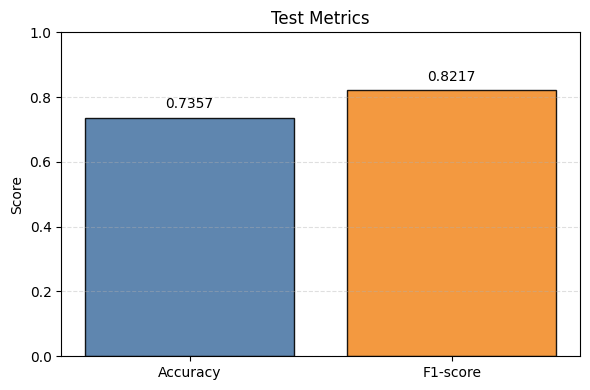

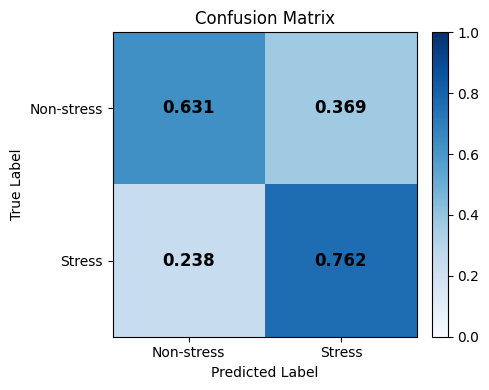

{'accuracy': 0.7357032457496137,
 'f1_score': 0.821689259645464,
 'confusion_matrix_count': [[82, 48], [123, 394]],
 'confusion_matrix_row_ratio': [[0.6307692307692307, 0.36923076923076925],
  [0.2379110251450677, 0.7620889748549323]]}

In [2]:
# Test set 평가 + 시각화: Accuracy/F1 bar graph, Confusion Matrix(row-normalized)
import numpy as np
import matplotlib.pyplot as plt

if "result" not in globals():
    raise RuntimeError("먼저 1번 셀을 실행해 result를 생성해 주세요.")

if "test_metrics" not in result:
    raise RuntimeError("result에 test_metrics가 없습니다. 1번 셀 실행 결과를 확인해 주세요.")

tm = result["test_metrics"]

accuracy = float(tm.get("accuracy", 0.0))
f1_score = float(tm.get("f1", 0.0))
tn = float(tm.get("tn", 0.0))
fp = float(tm.get("fp", 0.0))
fn = float(tm.get("fn", 0.0))
tp = float(tm.get("tp", 0.0))

conf_mat = np.array([[tn, fp], [fn, tp]], dtype=np.float64)
row_sums = conf_mat.sum(axis=1, keepdims=True)
conf_mat_ratio = np.divide(conf_mat, np.maximum(row_sums, 1.0))

print("=== Test Evaluation ===")
print(f"Model: {result.get('model_name', 'hr_1dcnn_transformer_torch')}")
print(f"Device: {result.get('device', 'unknown')}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1_score:.4f}")
print("Confusion Matrix Count [[TN, FP], [FN, TP]]:")
print(conf_mat.astype(int))
print("Confusion Matrix Row Ratio [[TN, FP], [FN, TP]]:")
print(np.round(conf_mat_ratio, 4))

# 1) Accuracy / F1-score bar graph
metrics = ["Accuracy", "F1-score"]
values = [accuracy, f1_score]
colors = ["#4e79a7", "#f28e2b"]

plt.figure(figsize=(6, 4))
bars = plt.bar(metrics, values, color=colors, edgecolor="black", alpha=0.9)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Test Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.4)
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.4f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# 2) Confusion Matrix graph (row-normalized heatmap)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(conf_mat_ratio, cmap="Blues", vmin=0.0, vmax=1.0)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Non-stress", "Stress"])
ax.set_yticklabels(["Non-stress", "Stress"])
for i in range(conf_mat_ratio.shape[0]):
    for j in range(conf_mat_ratio.shape[1]):
        ax.text(
            j,
            i,
            f"{conf_mat_ratio[i, j]:.3f}",
            ha="center",
            va="center",
            color="black",
            fontsize=12,
            fontweight="bold",
        )
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

{
    "accuracy": accuracy,
    "f1_score": f1_score,
    "confusion_matrix_count": conf_mat.astype(int).tolist(),
    "confusion_matrix_row_ratio": conf_mat_ratio.tolist(),
}

In [3]:
# Dataset split 출력 (subject-wise)
if "result" in globals() and "subject_splits" in result:
    split_info = result["subject_splits"]
elif "splits" in globals():
    split_info = globals()["splits"]
else:
    raise RuntimeError("먼저 1번 셀을 실행해 dataset split을 생성해 주세요.")

print("=== Dataset Split (35/5/10) ===")
for split_name in ["train", "val", "test"]:
    subjects_in_split = split_info.get(split_name, [])
    print(f"{split_name.upper()} ({len(subjects_in_split)} subjects):")
    print(subjects_in_split)
    print("-")

split_summary = {k: len(v) for k, v in split_info.items()}
print("Split counts:", split_summary)
split_summary

=== Dataset Split (35/5/10) ===
TRAIN (35 subjects):
['Sub4', 'Sub5', 'Sub6', 'Sub8', 'Sub10', 'Sub11', 'Sub16', 'Sub17', 'Sub18', 'Sub20', 'Sub22', 'Sub23', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30', 'Sub31', 'Sub32', 'Sub33', 'Sub34', 'Sub35', 'Sub37', 'Sub41', 'Sub42', 'Sub43', 'Sub44', 'Sub45', 'Sub46', 'Sub47', 'Sub48', 'Sub49', 'Sub50', 'Sub51', 'Sub53']
-
VAL (5 subjects):
['Sub7', 'Sub12', 'Sub21', 'Sub24', 'Sub38']
-
TEST (10 subjects):
['Sub1', 'Sub2', 'Sub3', 'Sub9', 'Sub13', 'Sub14', 'Sub15', 'Sub36', 'Sub40', 'Sub52']
-
Split counts: {'train': 35, 'val': 5, 'test': 10}


{'train': 35, 'val': 5, 'test': 10}

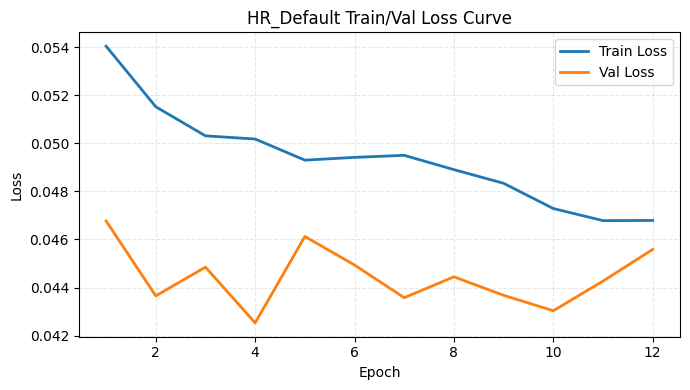

,epoch,train_loss,val_loss
7,8.0,0.048906,0.044447
8,9.0,0.048338,0.043678
9,10.0,0.047288,0.043036
10,11.0,0.046785,0.044268
11,12.0,0.046791,0.045585


In [4]:
# Train/Val loss 곡선 (HR_Default)
import pandas as pd
import matplotlib.pyplot as plt

if "result" not in globals():
    raise RuntimeError("먼저 1번 셀을 실행해 result를 생성해 주세요.")

history_rows = result.get("history", [])
if len(history_rows) == 0:
    raise RuntimeError("result에 history가 없습니다. 1번 셀 학습 결과를 확인해 주세요.")

history_df = pd.DataFrame(history_rows)
required_cols = {"train_loss", "val_loss"}
if not required_cols.issubset(set(history_df.columns)):
    raise ValueError(f"history에 필요한 컬럼이 없습니다. 필요: {required_cols}, 실제: {set(history_df.columns)}")

if "epoch" not in history_df.columns:
    history_df = history_df.copy()
    history_df["epoch"] = range(1, len(history_df) + 1)

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss", linewidth=2)
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss", linewidth=2)
plt.title("HR_Default Train/Val Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

history_df[["epoch", "train_loss", "val_loss"]].tail()

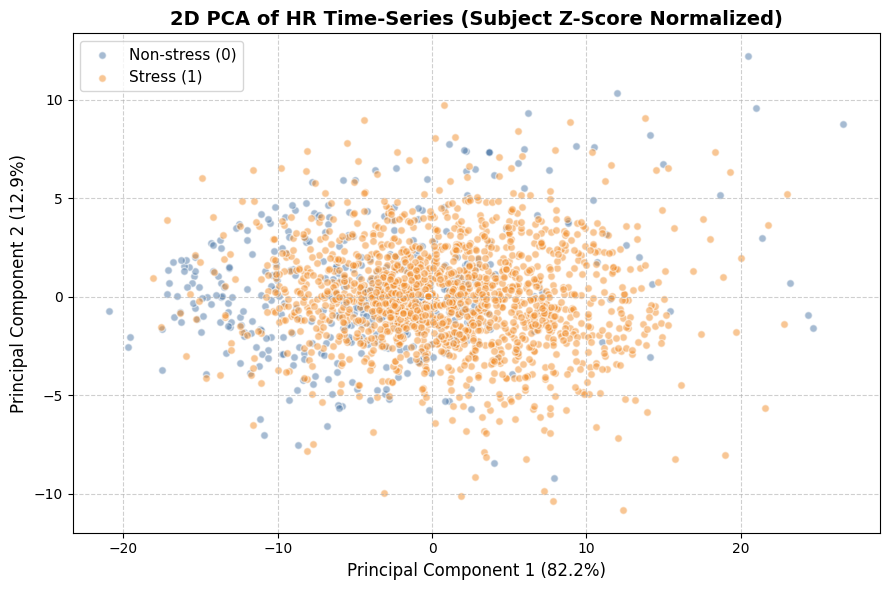

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path

# 1. result 딕셔너리에서 학습 피험자 정보와 설정값 가져오기
train_subjects = result['subject_splits']['train']
dataset_root = Path(result['dataset_root'])

# 2. 전처리된 학습 데이터 로드 (Subject Z-score가 적용된 상태)
x_train_pca, y_train_pca = build_split_arrays(
    dataset_root, 
    train_subjects, 
    hp.window_size, 
    hp.stride, 
    normalization_mode=hp.normalization_mode
)

# 3. 데이터 차원 축소: (샘플 수, 1, 60) -> (샘플 수, 60)으로 평탄화(Flatten)
x_train_2d = x_train_pca.reshape(x_train_pca.shape[0], -1)

# 4. PCA 모델 생성 및 학습 (60차원 -> 2차원으로 압축)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_train_2d)

# 5. 시각화 (Scatter Plot)
plt.figure(figsize=(9, 6))

# Non-stress (y=0) 파란색 점
plt.scatter(x_pca[y_train_pca == 0, 0], x_pca[y_train_pca == 0, 1], 
            color='#4e79a7', alpha=0.5, label='Non-stress (0)', edgecolors='w', s=30)

# Stress (y=1) 주황/빨간색 점
plt.scatter(x_pca[y_train_pca == 1, 0], x_pca[y_train_pca == 1, 1], 
            color='#f28e2b', alpha=0.5, label='Stress (1)', edgecolors='w', s=30)

# 그래프 꾸미기 (각 주성분이 원본 데이터를 얼마나 잘 설명하는지 분산 비율 표시)
plt.title('2D PCA of HR Time-Series (Subject Z-Score Normalized)', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 출력
plt.show()